## 1 Importation bibliothèques

In [3]:
#%pip install scikit-learn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score)

from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn import tree


## 2 Chargement données et aperçu

In [5]:
data_mat = pd.read_csv("BDD_initial/student-mat.csv", sep=",", index_col=0)
data_mat.head()
data_por = pd.read_csv("BDD_initial/student-por.csv", sep=",", index_col=0)
data_por.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [6]:
y = data_mat["Dalc"]
y
X = data_mat[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]

y_por = data_por["Dalc"]
y_por
X_por = data_por[["G1", "G2", "G3", "freetime", "goout", "health", "absences", "age", "studytime", "Mjob","Fjob", "reason", "activities","romantic"]]


In [7]:
categorical_cols = data_mat.drop(["Dalc","Walc"],axis=1).columns
data_mat1 = data_mat.drop(["Dalc","Walc"],axis=1)
categorical_cols

categorical_cols_por = data_por.drop(["Dalc","Walc"],axis=1).columns
data_por1 = data_por.drop(["Dalc","Walc"],axis=1)
categorical_cols_por

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [8]:
print(data_mat1.dtypes)
print(data_mat1.isnull().sum())
data_mat1.describe()

sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
go

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
print(data_por1.dtypes)
print(data_por1.isnull().sum())
data_por1.describe()

sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
go

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


data_mat2 = data_mat1.copy()

#variables à transformer de texte en nombre

categorical_cols = data.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

In [10]:
data_mat2 = data_mat1.copy()

#variables à transformer de texte en nombre

categorical_cols = data_mat2.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

Variables catégorielles à encoder : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\sidsm\AppData\Local\Temp\ipykernel_22004\563523784.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_mat2.select_dtypes(include='object').columns


In [11]:
data_por2 = data_por1.copy()

#variables à transformer de texte en nombre

categorical_cols = data_por2.select_dtypes(include='object').columns
print(f"Variables catégorielles à encoder : {list(categorical_cols)}")

Variables catégorielles à encoder : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\sidsm\AppData\Local\Temp\ipykernel_22004\3648053518.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_por2.select_dtypes(include='object').columns


## 3 Prétraitement des données

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_mat2[col] = le.fit_transform(data_mat2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_mat2.head()

  sex: {'F': np.int64(0), 'M': np.int64(1)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  Mjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  Fjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  reason: {'course': np.int64(0), 'home': np.int64(1), 'other': np.int64(2), 'reputation': np.int64(3)}
  guardian: {'father': np.int64(0), 'mother': np.int64(1), 'other': np.int64(2)}
  schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
  famsup: {'no': np.int64(0), 'yes': np.int64(1)}
  paid: {'no': np.int64(0), 'yes': np.int64(1)}
  activities: {'no': np.int64(0), 'yes': np.int64(1)}
  nursery: {'no': np.int64(0), 'yes': np.int64(1)}
  higher: {'no': np.int64(0), 'yes': np.int64(1)}
  internet: {'no': np.int64(0), 'yes': np.int64(1)}
  romantic:

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,6,5,6,6
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,4,5,5,6
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,10,7,8,10
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,2,15,14,15
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,4,6,10,10


In [13]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_por2[col] = le.fit_transform(data_por2[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_por2.head()

  sex: {'F': np.int64(0), 'M': np.int64(1)}
  address: {'R': np.int64(0), 'U': np.int64(1)}
  famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
  Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
  Mjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  Fjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
  reason: {'course': np.int64(0), 'home': np.int64(1), 'other': np.int64(2), 'reputation': np.int64(3)}
  guardian: {'father': np.int64(0), 'mother': np.int64(1), 'other': np.int64(2)}
  schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
  famsup: {'no': np.int64(0), 'yes': np.int64(1)}
  paid: {'no': np.int64(0), 'yes': np.int64(1)}
  activities: {'no': np.int64(0), 'yes': np.int64(1)}
  nursery: {'no': np.int64(0), 'yes': np.int64(1)}
  higher: {'no': np.int64(0), 'yes': np.int64(1)}
  internet: {'no': np.int64(0), 'yes': np.int64(1)}
  romantic:

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,0,18,1,0,0,4,4,0,4,0,...,0,0,4,3,4,3,4,0,11,11
GP,0,17,1,0,1,1,1,0,2,0,...,1,0,5,3,3,3,2,9,11,11
GP,0,15,1,1,1,1,1,0,2,2,...,1,0,4,3,2,3,6,12,13,12
GP,0,15,1,0,1,4,2,1,3,1,...,1,1,3,2,2,5,0,14,14,14
GP,0,16,1,0,1,3,3,2,2,1,...,0,0,4,3,2,5,0,11,13,13


## 4 Entrainement de différents modèles d'apprentissage

La première méthode consiste à effectuer l'entrainement des données à l'aide de la fonction 'cross_val_score' qui sépare le jeu de donnée en 'cv=4' groupe avant d'entrainer les données sur chacun d'entre eux et tester son score sur le dernier groupe.

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier



clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2,
    random_state=0)
scores = cross_val_score(clf, data_mat2, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=0)
scores = cross_val_score(clf, data_mat2, y, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=1)
scores = cross_val_score(clf, data_mat2, y, cv=5)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899
[0.70886076 0.69620253 0.69620253 0.69620253 0.69620253]
0.6987341772151899


np.False_

In [15]:
clf = DecisionTreeClassifier(max_depth=1, min_samples_split=2,
    random_state=0)
scores = cross_val_score(clf, data_por2, y_por, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = RandomForestClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=0)
scores = cross_val_score(clf, data_por2, y_por, cv=5)
scores.mean()
print(scores)
print(scores.mean())

clf = ExtraTreesClassifier(n_estimators=100, max_depth=1,
    min_samples_split=2, random_state=1)
scores = cross_val_score(clf, data_por2, y_por, cv=5)
print(scores)
print(scores.mean())

scores.mean() > 0.999

[0.7        0.69230769 0.69230769 0.69230769 0.69767442]
0.6949194991055456
[0.7        0.69230769 0.69230769 0.69230769 0.69767442]
0.6949194991055456
[0.7        0.69230769 0.69230769 0.69230769 0.69767442]
0.6949194991055456


np.False_

In [16]:
    
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(data_mat2, y, test_size=0.3, random_state=0)
X_train_por, X_test_por, y_train_por, y_test_por = train_test_split(data_por2, y_por, test_size=0.3, random_state=0)

model_0 = DecisionTreeRegressor()
model_6 = LogisticRegression(random_state=1)
model_7 = GaussianNB()
model_1 = SGDClassifier(random_state=1)
model_2 = DecisionTreeClassifier()
model_3 = KNeighborsClassifier(n_neighbors=2)

model_4 = VotingClassifier([('SGD', model_1),
                            ('Tree', model_2),
                            ('lr', model_6),
                            ('KNN', model_3)],
                          voting='hard')
Best=None
score_Best=0
for model in (model_0, model_1, model_2, model_3, model_4,model_6,model_7):
    model.fit(X_train, y_train)
    if model.score(X_test, y_test)>score_Best:
        Best=model
        
    print(model.__class__.__name__, model.score(X_test, y_test))
print("modélisation Portuhais :\n")

Best_por=None
score_Best_por=0
for model in (model_0, model_1, model_2, model_3, model_4,model_6,model_7):
    model.fit(X_train_por, y_train_por)
    if model.score(X_test_por, y_test_por)>score_Best:
        Best=model 
    print(model.__class__.__name__, model.score(X_test_por, y_test_por))


DecisionTreeRegressor -0.9599045888232611
SGDClassifier 0.7142857142857143
DecisionTreeClassifier 0.5882352941176471
KNeighborsClassifier 0.6890756302521008
VotingClassifier 0.7142857142857143
LogisticRegression 0.7142857142857143
GaussianNB 0.3025210084033613
modélisation Portuhais :

DecisionTreeRegressor -1.3090053515408746
SGDClassifier 0.676923076923077
DecisionTreeClassifier 0.558974358974359
KNeighborsClassifier 0.6512820512820513


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

VotingClassifier 0.6974358974358974
LogisticRegression 0.6871794871794872
GaussianNB 0.3282051282051282


c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

In [17]:
# Métriques
y_pred_base = Best.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_base)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2   = r2_score(y_test, y_pred_base)

print("=== Résultats — Modèle de Base ===")
print(f"  MAE  (erreur absolue moyenne) : {mae:.3f}")
print(f"  RMSE (racine erreur quadr.)   : {rmse:.3f}")
print(f"  R²   (coefficient de détermination) : {r2:.3f}")
print(f"\n Le modèle explique {r2*100:.1f}% de la variance du score")


=== Résultats — Modèle de Base ===
  MAE  (erreur absolue moyenne) : 1.647
  RMSE (racine erreur quadr.)   : 2.098
  R²   (coefficient de détermination) : -6.083

 Le modèle explique -608.3% de la variance du score


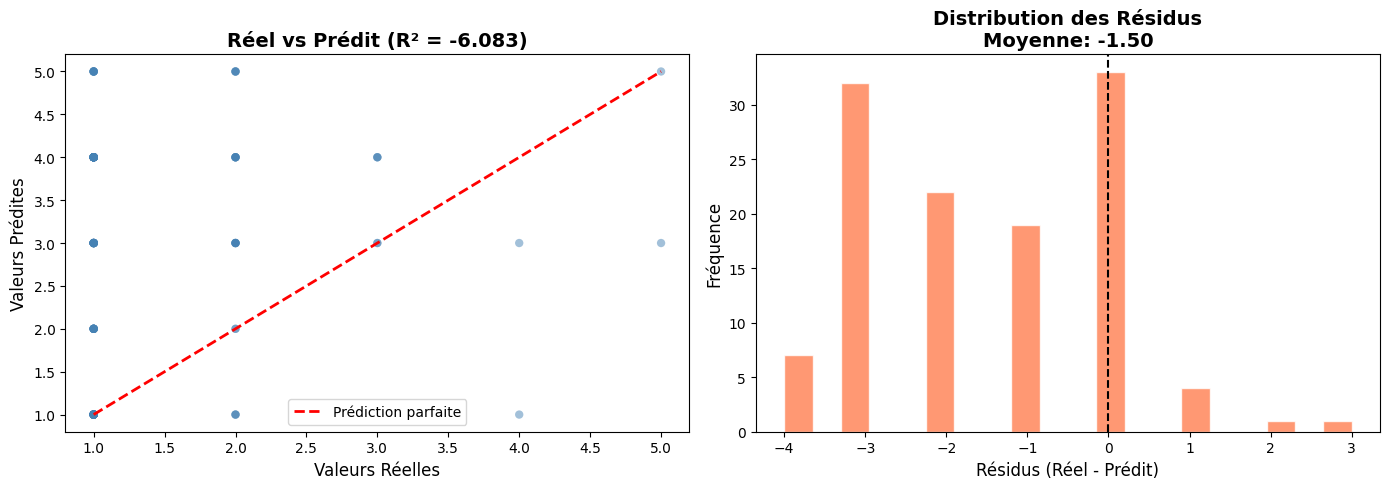

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prédictions vs Valeurs Réelles
axes[0].scatter(y_test, y_pred_base, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles', fontsize=12)
axes[0].set_ylabel('Valeurs Prédites', fontsize=12)
axes[0].set_title(f'Réel vs Prédit (R² = {r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()

# Distribution des Résidus
residuals = y_test - y_pred_base
axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.2f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Validation croisée (5-fold)
cv_scores = cross_val_score(Best, data_mat2, y, cv=5, scoring='r2')

print("=== Validation Croisée (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R^2 moyen  : {cv_scores.mean():.4f}")
print(f"  Écart-type : {cv_scores.std():.4f}")


=== Validation Croisée (5-fold) ===
  Fold 1: R² = -6.2923
  Fold 2: R² = -6.3159
  Fold 3: R² = -4.5364
  Fold 4: R² = -6.3616
  Fold 5: R² = -5.6771

  R^2 moyen  : -5.8367
  Écart-type : 0.6970


[Text(0.5039655172413793, 0.9722222222222222, 'x[8] <= 1.5\ngini = 0.496\nsamples = 276\nvalue = [187, 54, 21, 7, 7]'),
 Text(0.2289655172413793, 0.9166666666666666, 'x[4] <= 3.5\ngini = 0.652\nsamples = 72\nvalue = [36, 18, 13, 1, 4]'),
 Text(0.3664655172413793, 0.9444444444444444, 'True  '),
 Text(0.13517241379310344, 0.8611111111111112, 'x[7] <= 17.5\ngini = 0.518\nsamples = 43\nvalue = [28.0, 9.0, 5.0, 1.0, 0.0]'),
 Text(0.06620689655172414, 0.8055555555555556, 'x[5] <= 4.5\ngini = 0.395\nsamples = 33\nvalue = [25, 5, 3, 0, 0]'),
 Text(0.027586206896551724, 0.75, 'x[6] <= 9.0\ngini = 0.133\nsamples = 14\nvalue = [13, 0, 1, 0, 0]'),
 Text(0.016551724137931035, 0.6944444444444444, 'gini = 0.0\nsamples = 10\nvalue = [10, 0, 0, 0, 0]'),
 Text(0.038620689655172416, 0.6944444444444444, 'x[4] <= 2.5\ngini = 0.375\nsamples = 4\nvalue = [3, 0, 1, 0, 0]'),
 Text(0.027586206896551724, 0.6388888888888888, 'gini = 0.0\nsamples = 3\nvalue = [3, 0, 0, 0, 0]'),
 Text(0.0496551724137931, 0.63888888

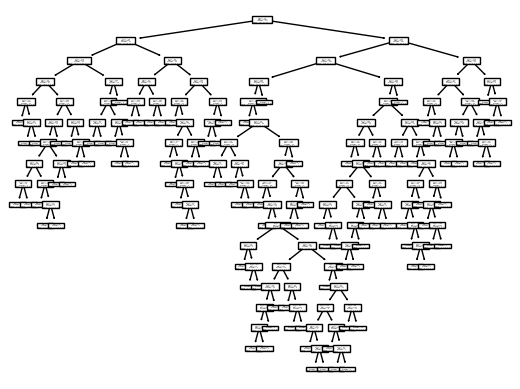

In [ ]:
tree.plot_tree(model_2)

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [ ]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100)


model.fit(X_train, y_train)
model.score(X_test, y_test)

0.6722689075630253

In [ ]:
model = RandomForestClassifier(n_estimators=100, max_depth=3)

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [ ]:
best = 0
best_k=0
for k in range (1,100,1):
    model = AdaBoostClassifier(n_estimators=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    if(best<score):
        best=score
        best_k=k
    if(score>0.73):
        print(k,score)
print("best : ",best_k,best)

1 0.7478991596638656
2 0.7478991596638656
3 0.7478991596638656
4 0.7478991596638656
5 0.7478991596638656
6 0.7478991596638656
7 0.7478991596638656
8 0.7478991596638656
9 0.7478991596638656
10 0.7478991596638656
11 0.7478991596638656
12 0.7478991596638656
13 0.7394957983193278
15 0.7394957983193278
17 0.7394957983193278
25 0.7394957983193278
best :  1 0.7478991596638656


In [ ]:
model = AdaBoostClassifier(n_estimators=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [ ]:

model = GradientBoostingClassifier(n_estimators=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7478991596638656

In [ ]:
%pip install xgboost
from xgboost import XGBRegressor

^C
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'xgboost'

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 4.2 MB/s eta 0:00:25
    --------------------------------------- 1.3/101.7 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 2.1/101.7 MB 2.9 MB/s eta 0:00:34
   - -------------------------------------- 2.6/101.7 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 3.4/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 3.9/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 4.5/101.7 MB 2.9 MB/s eta 0:00:35
   - -------------------------------------- 5.0/101.7 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 5.5/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 6.0/101.7 MB 2.8 MB/s eta 0:00:35
   -- -

In [ ]:
from sklearn.ensemble import StackingClassifier
model = StackingClassifier([('Tree', model_2),
                            ('lr', model_6),
                            ('KNN', model_3),
                            ('voting', model_4)],
                             final_estimator=DecisionTreeClassifier())

model.fit(X_train, y_train)
model.score(X_test, y_test)

c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Pl

0.5882352941176471

In [25]:
%pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [27]:
xgb_model = XGBRegressor(
   n_estimators=100,     # nombre d'arbres dans la séquence
   learning_rate=0.1,    # de combien chaque arbre "corrige" (0 à 1)
   max_depth=6,          # profondeur max de chaque arbre
   random_state=42
)


xgb_model.fit(X_train, y_train)
print("Modèle entraîné !")

xgb_model.score(X_test,y_test)

Modèle entraîné !


-0.2528715133666992